# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [1]:

# Importing necessary libraries
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from locale import normalize
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

In [2]:
DATA_PATH   = 'data/Car_Price_data.csv'
IMAGES_PATH = 'images/'
THRESHOLD_LEVEL = 0.05
os.makedirs(IMAGES_PATH, exist_ok=True)
KEEP_MIN = 0.05
KEEP_MAX = 0.95
RANDOM_STATE = 42

#### **1.1.1**
Load the dataset

In [3]:
# Load the data
car_price_df = pd.read_csv(DATA_PATH)
car_price_df.shape


(15915, 23)

In [4]:
car_price_df.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


In [5]:
car_price_df.dtypes

make_model                 str
body_type                  str
price                    int64
vat                        str
km                     float64
Type                       str
Fuel                       str
Gears                  float64
Comfort_Convenience        str
Entertainment_Media        str
Extras                     str
Safety_Security            str
age                    float64
Previous_Owners        float64
hp_kW                  float64
Inspection_new           int64
Paint_Type                 str
Upholstery_type            str
Gearing_Type               str
Displacement_cc        float64
Weight_kg              float64
Drive_chain                str
cons_comb              float64
dtype: object

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [6]:
def missing_values_report(df: pd.DataFrame):
    total_rows = df.shape[0]
    placeholders = ['','nan','none','null','-','na','n/a','unknown','?']
    rows = []
    for column in df.columns:

        entry = {'column':column,
                 'dtype':str(df[column].dtype),
                 'nulls':df[column].isnull().sum(),
                 'placeholder':0,
                 'zero':0,
                 'negative':0}
        if pd.api.types.is_numeric_dtype(df[column]) :
            entry['zero'] = (df[column]==0).sum()
            entry['negative'] = (df[column]<0).sum()
        elif pd.api.types.is_string_dtype(df[column]) :
            cleaned = df[column].str.strip().str.lower()
            entry['placeholder'] = cleaned.isin(placeholders).sum()
        else :
            entry['placeholder'] = 0

        rows.append(entry)

    report = pd.DataFrame(rows).set_index('column')
    return report.loc[report[['nulls','placeholder','zero','negative']].sum(axis=1)>0]

In [7]:
# Find the proportion of missing values in each column and handle if found
issues = missing_values_report(car_price_df)
print("===============Missing Values Report===================\n")
print(issues if not issues.empty else "Not Found!")

===============Missing Values Report===================

                   dtype  nulls  placeholder   zero  negative
column                                                       
km               float64      0            0     19         0
age              float64      0            0   4433         0
Previous_Owners  float64      0            0    554         0
Inspection_new     int64      0            0  11983         0


In [8]:
car_price_df.loc[car_price_df['age']==0].groupby('Previous_Owners')['age'].count()

Previous_Owners
0.0     514
1.0    3901
2.0      18
Name: age, dtype: int64

In [9]:
car_price_df.loc[car_price_df['make_model']=='Audi A1'].groupby('age')['make_model'].count()

age
0.0    806
1.0    747
2.0    432
3.0    629
Name: make_model, dtype: int64

In [10]:
car_price_df.loc[(car_price_df['age']==0) & ((car_price_df['Previous_Owners']==2) | (car_price_df['Previous_Owners']==1))][['km','Type','make_model','Previous_Owners']]

,km,Type,make_model,Previous_Owners
122,1.000000,New,Audi A1,1.0
707,1.000000,Pre-registered,Audi A1,1.0
710,10.000000,New,Audi A1,1.0
713,7000.000000,Used,Audi A1,1.0
732,200.000000,Pre-registered,Audi A1,1.0
...,...,...,...,...
15910,1647.362609,New,Renault Espace,1.0
15911,9900.000000,Used,Renault Espace,1.0
15912,15.000000,Pre-registered,Renault Espace,1.0
15913,10.000000,Pre-registered,Renault Espace,1.0


**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

In [11]:
car_price_df.select_dtypes(include='number').describe()

,price,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb
count,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000,15915.000000
mean,18024.380584,32089.995708,5.937355,1.389695,1.042853,88.499340,0.247063,1428.661891,1337.700534,4.832124
std,7381.679318,36977.214964,0.704772,1.121306,0.339178,26.674341,0.431317,275.804272,199.682385,0.867530
min,4950.000000,0.000000,5.000000,0.000000,0.000000,40.000000,0.000000,890.000000,840.000000,3.000000
25%,12850.000000,1920.500000,5.000000,0.000000,1.000000,66.000000,0.000000,1229.000000,1165.000000,4.100000
50%,16900.000000,20413.000000,6.000000,1.000000,1.000000,85.000000,0.000000,1461.000000,1295.000000,4.800000
75%,21900.000000,46900.000000,6.000000,2.000000,1.000000,103.000000,0.000000,1598.000000,1472.000000,5.400000
max,74600.000000,317000.000000,8.000000,3.000000,4.000000,294.000000,1.000000,2967.000000,2471.000000,9.100000


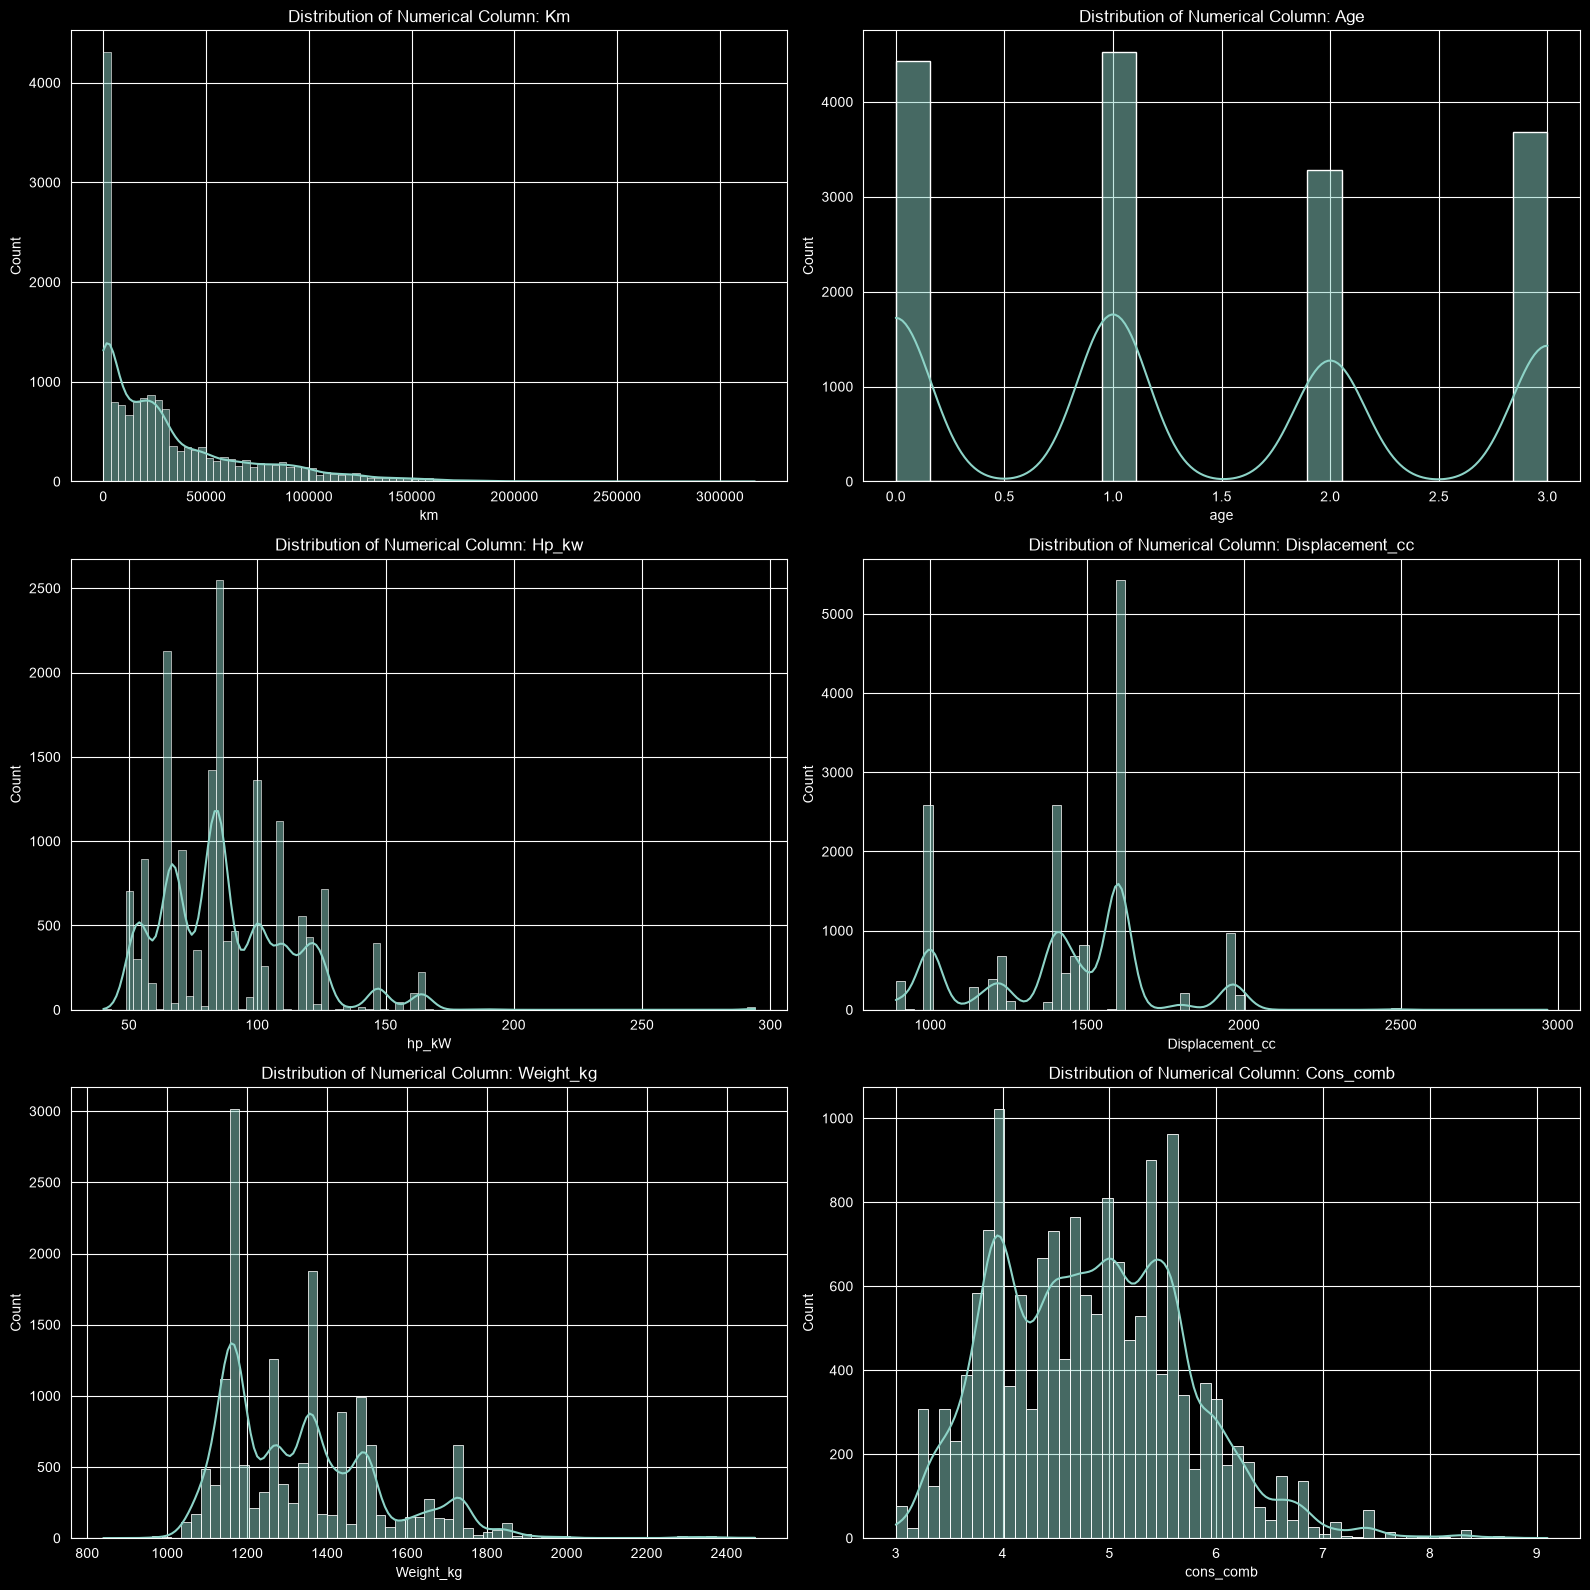

In [12]:
# Identify numerical features and plot histograms
numerical_predictors = ['km','age','hp_kW','Displacement_cc','Weight_kg','cons_comb']
fig,axes = plt.subplots(nrows=3,ncols=2,figsize=(16,16))
axes=axes.flatten()
for i,col in enumerate(numerical_predictors):
    sns.histplot(data=car_price_df,x=col, kde=True,ax=axes[i])
    axes[i].set_title(f"Distribution of Numerical Column: {col.capitalize()}")

plt.tight_layout()
plt.show()
fig.savefig(f"{IMAGES_PATH}numerical_distribution.png")

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

In [13]:
car_price_df.select_dtypes(include='string').columns

Index(['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience',
       'Entertainment_Media', 'Extras', 'Safety_Security', 'Paint_Type',
       'Upholstery_type', 'Gearing_Type', 'Drive_chain'],
      dtype='str')

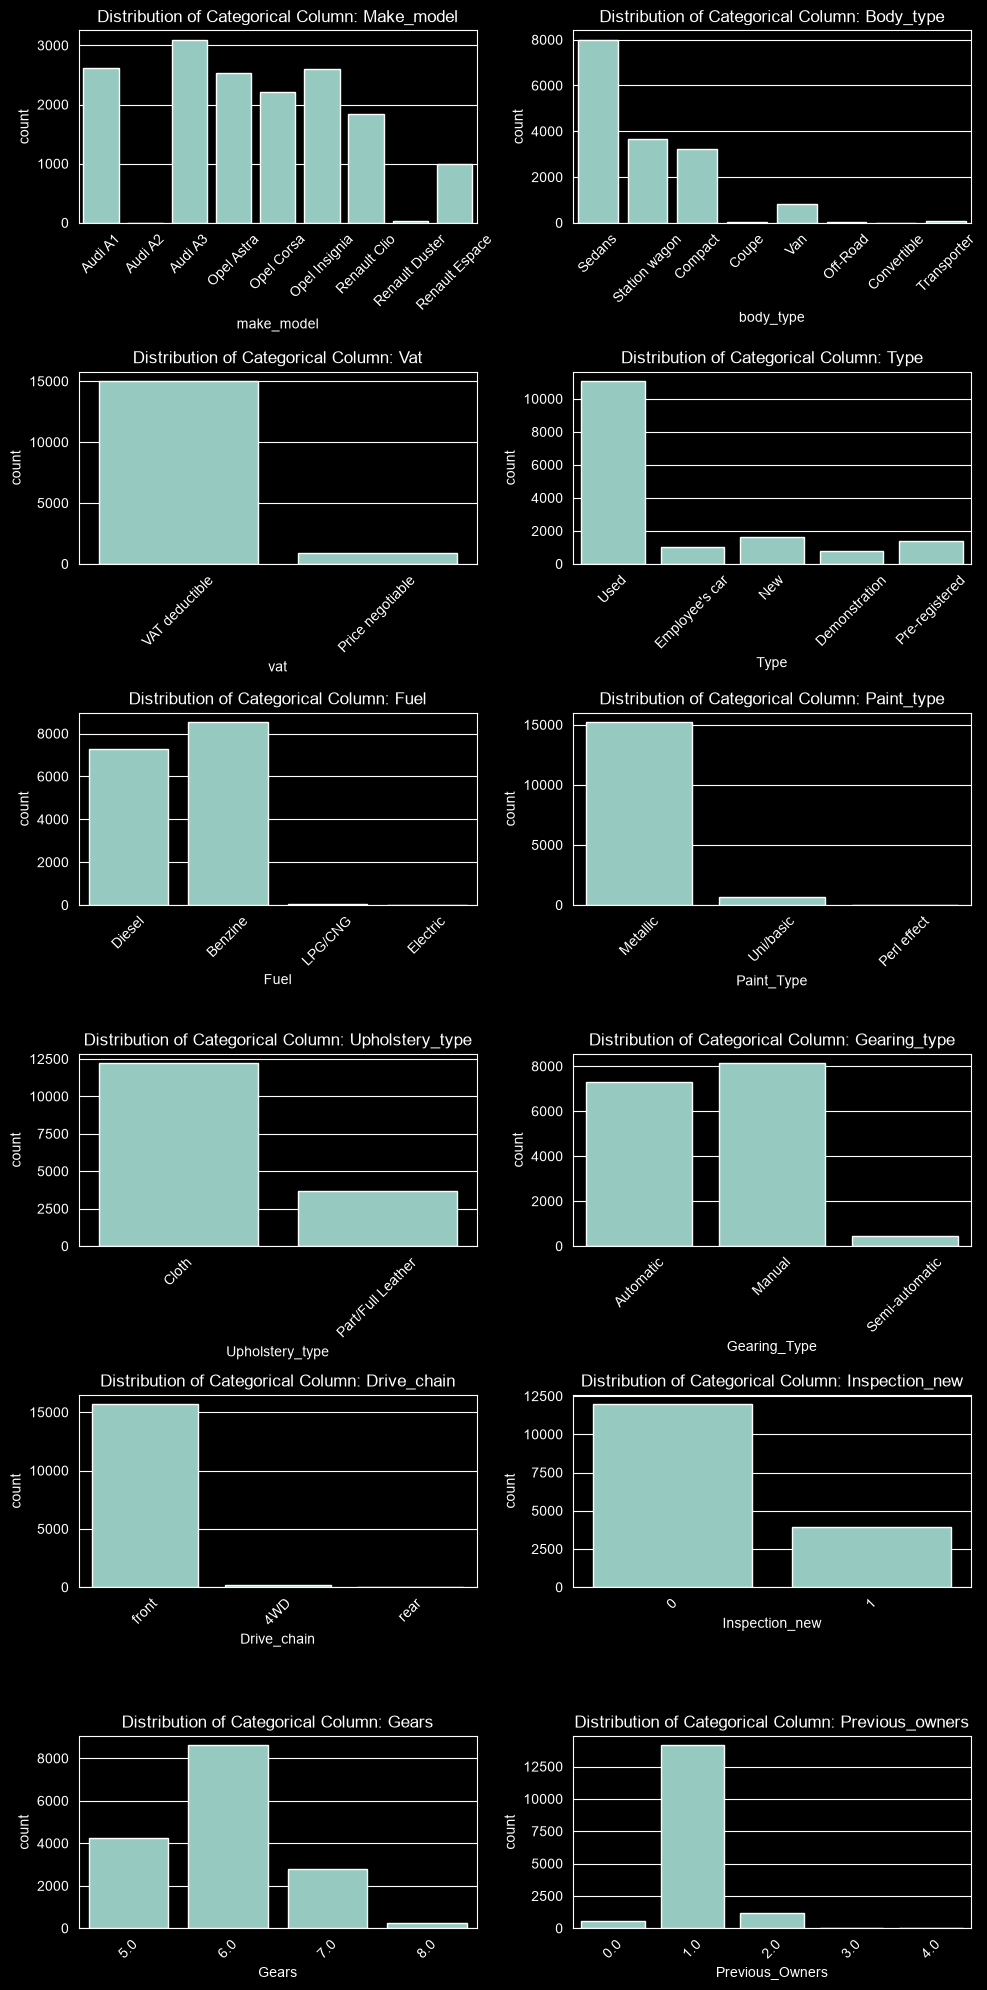

In [14]:
# Identify categorical columns and check their frequency distributions
categorical_predictors = ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type',
       'Upholstery_type', 'Gearing_Type', 'Drive_chain','Inspection_new','Gears','Previous_Owners']
fig,axes = plt.subplots(nrows=6,ncols=2,figsize=(10,20))
axes = axes.flatten()
for i,col in enumerate(categorical_predictors):
    sns.countplot(data=car_price_df,x=col,ax=axes[i])
    axes[i].set_title(f"Distribution of Categorical Column: {col.capitalize()}")
    axes[i].tick_params(axis='x',rotation=45)


plt.tight_layout()
plt.show()
fig.savefig(f"{IMAGES_PATH}categorical_distribution.png")

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [15]:
# Fix columns as needed
cols_to_merge = ['make_model', 'body_type', 'Fuel', 'Paint_Type', 'Gearing_Type', 'Drive_chain']
for col in cols_to_merge+['Gears','Previous_Owners']:
    tmp = car_price_df[col].value_counts(ascending=True).reset_index()
    tmp['percent'] = tmp['count']*100.0/(car_price_df[col].count())
    print(f"{tmp} \n")

       make_model  count    percent
0         Audi A2      1   0.006283
1  Renault Duster     34   0.213635
2  Renault Espace    991   6.226830
3    Renault Clio   1839  11.555137
4      Opel Corsa   2216  13.923971
5      Opel Astra   2525  15.865536
6   Opel Insignia   2598  16.324222
7         Audi A1   2614  16.424757
8         Audi A3   3097  19.459629 

       body_type  count    percent
0    Convertible      8   0.050267
1          Coupe     25   0.157085
2       Off-Road     56   0.351869
3    Transporter     88   0.552937
4            Van    817   5.133522
5        Compact   3240  20.358153
6  Station wagon   3677  23.103990
7         Sedans   8004  50.292177 

       Fuel  count    percent
0  Electric      5   0.031417
1   LPG/CNG     64   0.402136
2    Diesel   7298  45.856111
3   Benzine   8548  53.710336 

    Paint_Type  count    percent
0  Perl effect     32   0.201068
1    Uni/basic    637   4.002513
2     Metallic  15246  95.796418 

     Gearing_Type  count    percent

In [16]:
def merge_negligible_levels(series, threshold=0.05, other_label='Other'):
    frequency = series.value_counts(normalize=True)
    to_keep_index = frequency[frequency > threshold].index
    return series.where(series.isin(to_keep_index), other_label)


In [17]:
for col in cols_to_merge:
    car_price_df[col] = merge_negligible_levels(car_price_df[col], threshold=THRESHOLD_LEVEL)
    print(f"{col:12s} -> {car_price_df[col].value_counts().to_dict()}")

make_model   -> {'Audi A3': 3097, 'Audi A1': 2614, 'Opel Insignia': 2598, 'Opel Astra': 2525, 'Opel Corsa': 2216, 'Renault Clio': 1839, 'Renault Espace': 991, 'Other': 35}
body_type    -> {'Sedans': 8004, 'Station wagon': 3677, 'Compact': 3240, 'Van': 817, 'Other': 177}
Fuel         -> {'Benzine': 8548, 'Diesel': 7298, 'Other': 69}
Paint_Type   -> {'Metallic': 15246, 'Other': 669}
Gearing_Type -> {'Manual': 8149, 'Automatic': 7297, 'Other': 469}
Drive_chain  -> {'front': 15707, 'Other': 208}


In [18]:
car_price_df['Type'] = car_price_df['Type'].where(car_price_df['Type']=='Used','New-Like')
print(f"{'Type':12s} -> {car_price_df['Type'].value_counts().to_dict()}")

Type         -> {'Used': 11095, 'New-Like': 4820}


#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

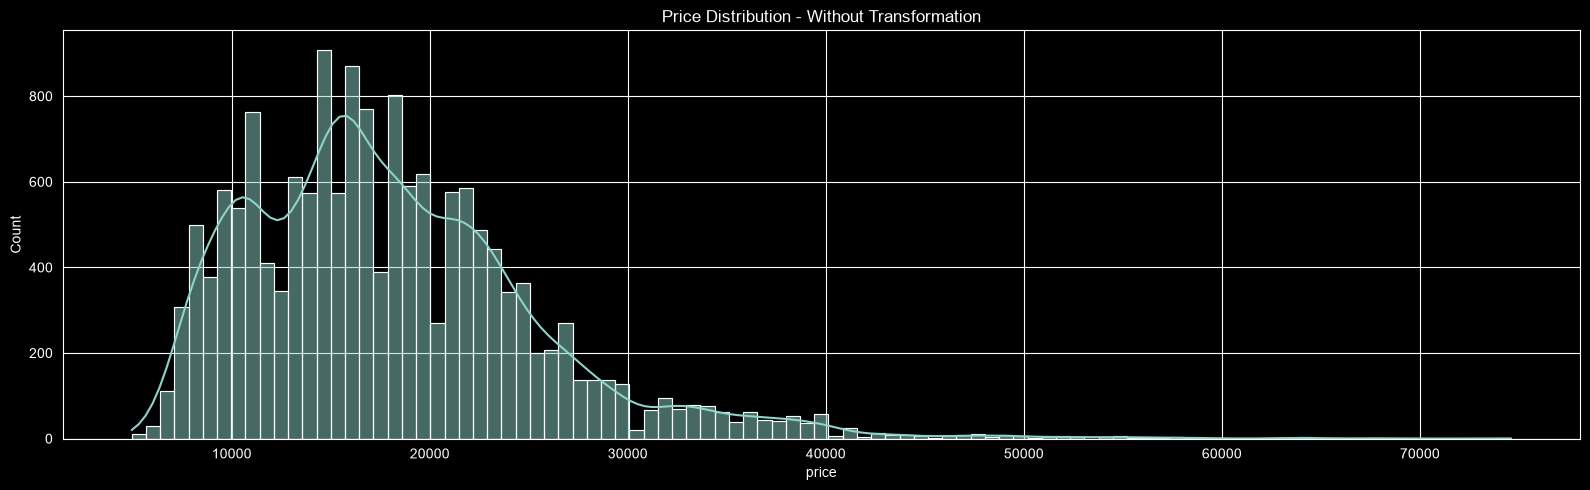

Skew of the price target - before transformation: 1.24


In [19]:
# Plot histograms for target feature
fig,axes = plt.subplots(nrows=1,ncols=1,figsize=(16,5))

sns.histplot(data=car_price_df,x=car_price_df['price'],kde=True,ax=axes)
axes.set_title("Price Distribution - Without Transformation")

plt.tight_layout()
plt.savefig(f"{IMAGES_PATH}price_distribution_before_transformation.png",dpi=150,bbox_inches='tight')
plt.show()

print(f"Skew of the price target - before transformation: {round(car_price_df['price'].skew(),2)}")

**The target variable seems to be skewed. Perform suitable transformation on the target.**

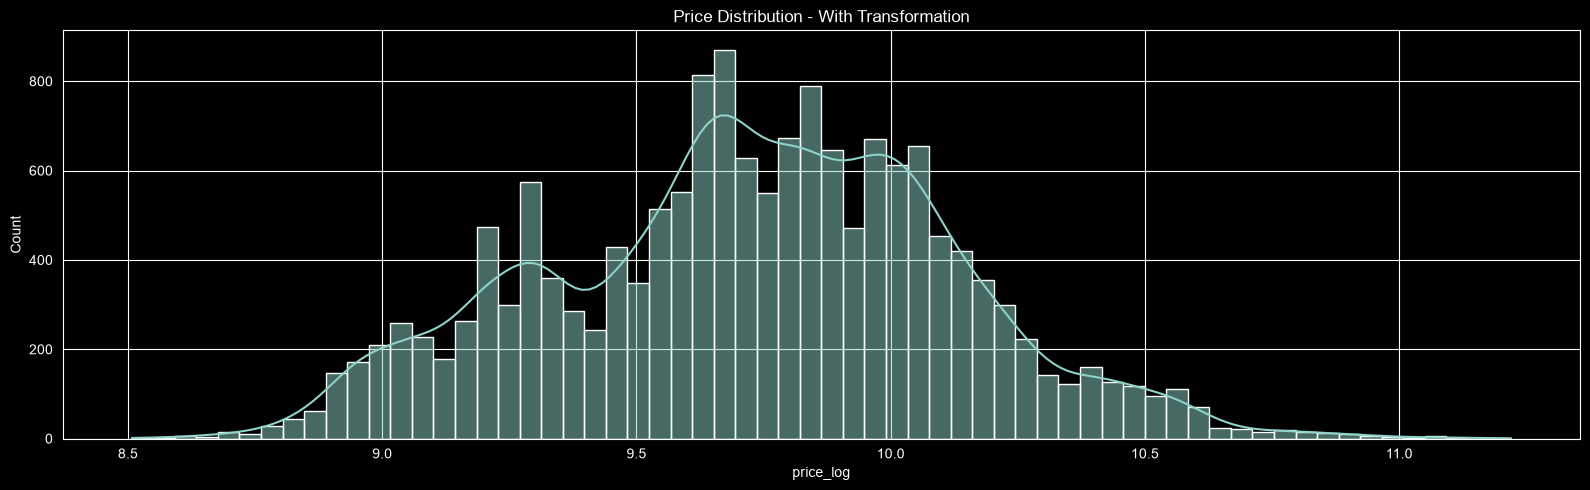

Skew of the price target - after transformation: -0.03


In [20]:
# Transform the target feature
car_price_df['price_log'] = np.log1p(car_price_df['price'])
fig,axes = plt.subplots(nrows=1,ncols=1,figsize=(16,5))

sns.histplot(data=car_price_df,x=car_price_df['price_log'],kde=True,ax=axes)
axes.set_title("Price Distribution - With Transformation")

plt.tight_layout()
plt.savefig(f"{IMAGES_PATH}price_distribution_after_transformation.png",dpi=150,bbox_inches='tight')
plt.show()

print(f"Skew of the price target - after transformation: {round(car_price_df['price_log'].skew(),2)}")


### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

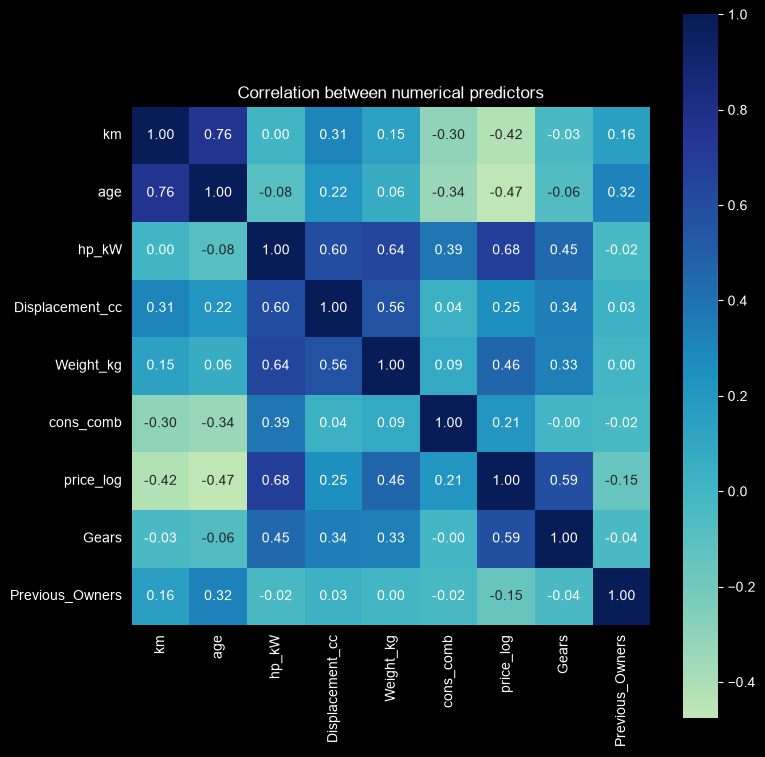

Correlation between numerical predictors and price(logged)-> 
{'km': -0.4191893750379163, 'age': -0.47461831267518967, 'hp_kW': 0.6780239221226255, 'Displacement_cc': 0.25485358399967883, 'Weight_kg': 0.4645970674985395, 'cons_comb': 0.21109746806982266, 'price_log': 1.0, 'Gears': 0.5881941954220993, 'Previous_Owners': -0.15202870650307915}


In [21]:
# Visualise correlation
num_df = car_price_df[numerical_predictors+['price_log','Gears','Previous_Owners']]
corr = num_df.corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, annot=True, fmt='.2f' ,cmap="YlGnBu",center=0,square=True)
plt.title("Correlation between numerical predictors")
plt.tight_layout()
plt.savefig(f"{IMAGES_PATH}correlation_heatmap.png")
plt.show()

print(f"Correlation between numerical predictors and price(logged)-> \n{corr['price_log'].to_dict()}")

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

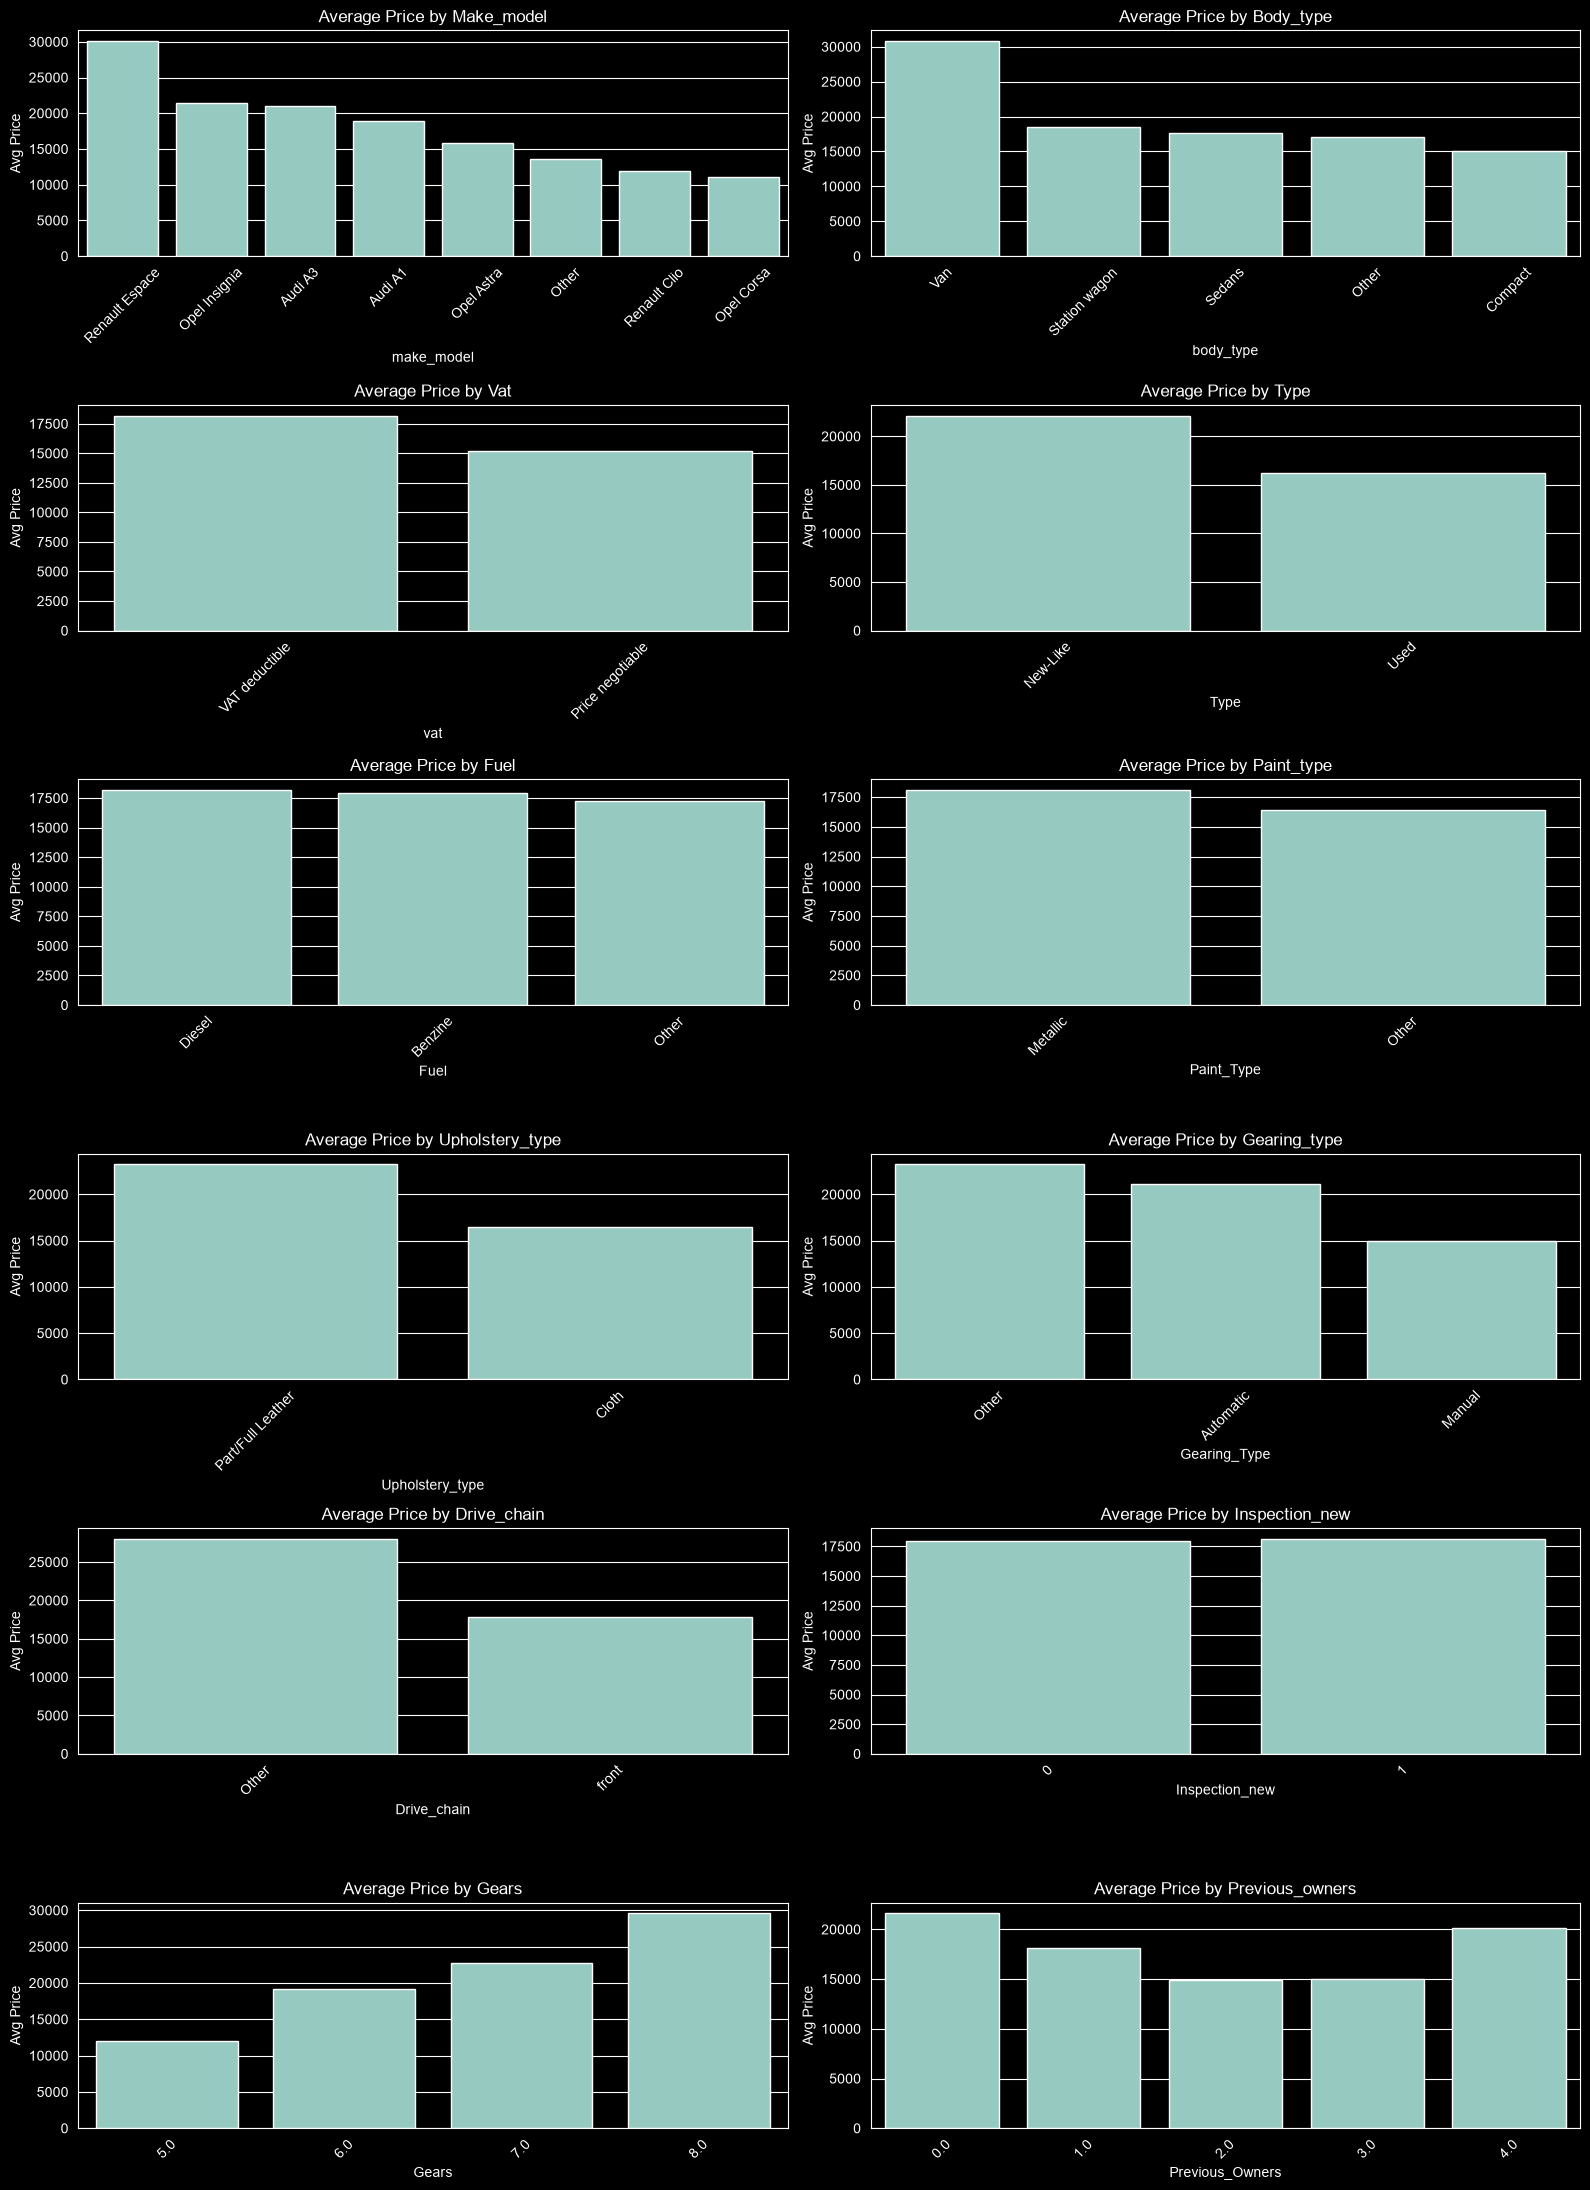

In [22]:
# Comparing average values of target for different categories
categorical_cols = ['make_model', 'body_type', 'vat', 'Type', 'Fuel','Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain','Inspection_new', 'Gears', 'Previous_Owners']
fig,axes = plt.subplots(nrows=6,ncols=2,figsize=(16,22))
axes = axes.flatten()

for index, column in enumerate(categorical_cols):
    avg_price = car_price_df.groupby(column)['price'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_price.index,y=avg_price.values, ax=axes[index])
    axes[index].set_title(f"Average Price by {column.capitalize()}")
    axes[index].set_ylabel("Avg Price")
    axes[index].tick_params(axis='x',rotation=45)

plt.tight_layout()
fig.savefig(f"{IMAGES_PATH}avg_price_distribution.png")
plt.show()

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

In [23]:
# Outliers present in each column
def get_summary(df: pd.DataFrame,column):
    summary = []
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    total_number_of_outliers_below_lower = (df[column]<lower_bound).sum()
    total_number_of_outliers_above_upper = (df[column]>upper_bound).sum()
    summary.append({
        'column': column,
        'max': df[column].max(),
        'min': df[column].min(),
        'Q1':Q1,
        'Q3':Q3,
        'IQR':IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'total_number_of_outliers_below_lower':total_number_of_outliers_below_lower,
        'total_number_of_outliers_above_upper':total_number_of_outliers_above_upper,
        'outlier_%':((total_number_of_outliers_below_lower + total_number_of_outliers_above_upper)*100.0 / df[column].shape[0])
    })
    return pd.DataFrame(summary)

In [24]:
numerical_columns = list(numerical_predictors+['price','Gears','Previous_Owners'])
for column in numerical_columns:
    print(f"======Summary for {column}===========")
    print(f"{get_summary(car_price_df,column).T}\n")

======Summary for km===========
                                              0
column                                       km
max                                    317000.0
min                                         0.0
Q1                                       1920.5
Q3                                      46900.0
IQR                                     44979.5
lower_bound                           -65548.75
upper_bound                           114369.25
total_number_of_outliers_below_lower          0
total_number_of_outliers_above_upper        689
outlier_%                              4.329249

======Summary for age===========
                                        0
column                                age
max                                   3.0
min                                   0.0
Q1                                    0.0
Q3                                    2.0
IQR                                   2.0
lower_bound                          -3.0
upper_bound           

In [25]:
car_price_df['km_per_year'] = car_price_df['km']/(car_price_df['age'] + 1)
car_price_df[['make_model', 'Type', 'age', 'km', 'km_per_year']].sort_values('km_per_year', ascending=False).head(20)

,make_model,Type,age,km,km_per_year
2901,Audi A3,Used,0.0,127022.0,127022.000000
9275,Opel Corsa,Used,2.0,317000.0,105666.666667
13728,Renault Clio,Used,0.0,105000.0,105000.000000
6396,Opel Astra,Used,0.0,88000.0,88000.000000
4031,Audi A3,Used,0.0,82400.0,82400.000000
15273,Renault Espace,Used,2.0,240000.0,80000.000000
9623,Opel Corsa,Used,0.0,76300.0,76300.000000
3003,Audi A3,Used,3.0,291800.0,72950.000000
4312,Audi A3,Used,1.0,136000.0,68000.000000
5712,Opel Astra,Used,3.0,260000.0,65000.000000


#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [26]:
# Handle outliers
impossible_mask = (car_price_df['age']==0) & (car_price_df['km']>50000)
print(f"Data which is impossible as per domain knowledge: {impossible_mask.sum()}\n")
print(car_price_df[impossible_mask].head(20))

car_price_df = car_price_df.loc[~impossible_mask].copy()
print("Rows remaining:", car_price_df.shape[0])

Data which is impossible as per domain knowledge: 5

         make_model      body_type  price             vat        km  Type  \
2901        Audi A3        Compact  15500  VAT deductible  127022.0  Used   
4031        Audi A3  Station wagon  17990  VAT deductible   82400.0  Used   
6396     Opel Astra         Sedans   6950  VAT deductible   88000.0  Used   
9623     Opel Corsa        Compact   9580  VAT deductible   76300.0  Used   
13728  Renault Clio  Station wagon   6900  VAT deductible  105000.0  Used   

          Fuel  Gears                                Comfort_Convenience  \
2901    Diesel    7.0  Air conditioning,Automatic climate control,Cru...   
4031    Diesel    6.0  Air conditioning,Automatic climate control,Nav...   
6396    Diesel    6.0  Air conditioning,Leather steering wheel,Multi-...   
9623   Benzine    5.0  Air conditioning,Cruise control,Electrical sid...   
13728  Benzine    5.0  Cruise control,Electrical side mirrors,Power w...   

                           

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [27]:
# Fix/create columns as needed
car_price_df['km_per_year'] = car_price_df['km'] / (car_price_df['age'] + 1)

car_price_df['hp_to_weight'] = car_price_df['hp_kW'] / (car_price_df['Weight_kg'])

print(car_price_df[['km', 'age', 'km_per_year', 'hp_kW', 'Weight_kg', 'hp_to_weight']].head())
print(car_price_df[['km_per_year', 'hp_to_weight']].describe())

        km  age   km_per_year  hp_kW  Weight_kg  hp_to_weight
0  56013.0  3.0  14003.250000   66.0     1220.0      0.054098
1  80000.0  2.0  26666.666667  141.0     1255.0      0.112351
2  83450.0  3.0  20862.500000   85.0     1135.0      0.074890
3  73000.0  3.0  18250.000000   66.0     1195.0      0.055230
4  16200.0  3.0   4050.000000   66.0     1135.0      0.058150
         km_per_year  hp_to_weight
count   15910.000000  15910.000000
mean    10339.035706      0.065663
std      9731.242867      0.015219
min         0.000000      0.032075
25%      1647.362609      0.056750
50%      8500.000000      0.062500
75%     14884.687500      0.072129
max    105666.666667      0.197980


#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [28]:
# Check unique values in each feature spec column
SPEC_COLUMNS = {'Comfort_Convenience':'cc',
                'Entertainment_Media':'em',
                'Extras':'ex',
                'Safety_Security':'ss',}

def expand_merged_column(series:pd.Series):
    cleaned = (series
               .fillna('')
               .str.replace(r'\s*,\s*', ',', regex=True)
               .str.strip())
    dummies = cleaned.str.get_dummies(sep=',')
    return dummies.drop(columns=[''],errors='ignore')

In [29]:
for column in SPEC_COLUMNS:
    dummies = expand_merged_column(car_price_df[column])
    prevalence = dummies.mean().sort_values(ascending=False)
    print(f"\n========== {column} : {dummies.shape[1]} distinct features ==========")
    print((prevalence*100).round(2).to_string())


========== Comfort_Convenience : 38 distinct features ==========
Air conditioning                       94.85
Power windows                          92.72
Electrical side mirrors                78.47
Multi-function steering wheel          73.80
Cruise control                         73.03
Park Distance Control                  66.95
Parking assist system sensors rear     63.39
Leather steering wheel                 61.18
Start-stop system                      59.42
Automatic climate control              57.79
Rain sensor                            56.95
Navigation system                      53.65
Light sensor                           50.50
Armrest                                47.77
Seat heating                           46.62
Hill Holder                            46.10
Parking assist system sensors front    38.36
Parking assist system camera           23.13
Lumbar support                         21.86
Heated steering wheel                  20.16
Keyless central door lock         

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [30]:
# Drop features from df
spec_features = []
for column,prefix in SPEC_COLUMNS.items():
    dummies = expand_merged_column(car_price_df[column])
    prevalence = dummies.mean().sort_values(ascending=False)
    keep_index = prevalence[((prevalence>=KEEP_MIN) & (prevalence<=KEEP_MAX))].index
    kept = dummies[keep_index].add_prefix(f"{prefix}_")

    print(f"{column:22s}: {kept.shape[1]} distinct features kept out of {dummies.shape[1]} features.\n")
    spec_features.append(kept)

Comfort_Convenience   : 27 distinct features kept out of 38 features.

Entertainment_Media   : 9 distinct features kept out of 10 features.

Extras                : 8 distinct features kept out of 17 features.

Safety_Security       : 27 distinct features kept out of 29 features.



In [31]:
car_price_df = pd.concat([car_price_df.drop(columns=SPEC_COLUMNS)]+spec_features,axis=1)
print(f"New DataFrame: {car_price_df.columns}")

New DataFrame: Index(['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel',
       'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new',
       'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc',
       'Weight_kg', 'Drive_chain', 'cons_comb', 'price_log', 'km_per_year',
       'hp_to_weight', 'cc_Air conditioning', 'cc_Power windows',
       'cc_Electrical side mirrors', 'cc_Multi-function steering wheel',
       'cc_Cruise control', 'cc_Park Distance Control',
       'cc_Parking assist system sensors rear', 'cc_Leather steering wheel',
       'cc_Start-stop system', 'cc_Automatic climate control',
       'cc_Rain sensor', 'cc_Navigation system', 'cc_Light sensor',
       'cc_Armrest', 'cc_Seat heating', 'cc_Hill Holder',
       'cc_Parking assist system sensors front',
       'cc_Parking assist system camera', 'cc_Lumbar support',
       'cc_Heated steering wheel', 'cc_Keyless central door lock',
       'cc_Split rear seats', 'cc_Electrically adjust

#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [32]:
# Encode features
categorical_columns = ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']
print(f"{"Shape before encoding":22s} : {car_price_df.shape}")
car_price_df = pd.get_dummies(car_price_df,columns=categorical_columns,drop_first=True,dtype=int)
print(f"{"Shape after encoding":22s} : {car_price_df.shape}")
# for testing
print("\nMake model columns created:", [c for c in car_price_df.columns if c.startswith('make_model_')])
print("Type columns created:", [c for c in car_price_df.columns if c.startswith('Type_')])

remaining_text = car_price_df.select_dtypes(exclude='number').columns.tolist()
print("\nNon-numeric columns remaining:", remaining_text if remaining_text else "none - all numeric")

Shape before encoding  : (15910, 93)
Shape after encoding   : (15910, 104)

Make model columns created: ['make_model_Audi A3', 'make_model_Opel Astra', 'make_model_Opel Corsa', 'make_model_Opel Insignia', 'make_model_Other', 'make_model_Renault Clio', 'make_model_Renault Espace']
Type columns created: ['Type_Used']

Non-numeric columns remaining: none - all numeric


#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [33]:
# Split data
target_column = 'price_log'
to_drop_columns = ['price','price_log']
X = car_price_df.drop(columns=to_drop_columns)
y = car_price_df[target_column]

print(f"Features For Model : {X.shape}")
print(f"Target Column : {y.shape}")

assert 'price' not in X.columns and 'price_log' not in X.columns, "A PRICE COLUMN EXISTS IN X!!!"

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=RANDOM_STATE)
print(f"\nTrain: {X_train.shape[0]} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Test: {X_test.shape[0]} rows ({X_test.shape[0]/len(X):.0%})")


print(f"Mean Price Log: training-> {y_train.mean()} || testing-> {y_test.mean()}")

Features For Model : (15910, 102)
Target Column : (15910,)

Train: 11137 rows (70%)
Test: 4773 rows (30%)
Mean Price Log: training-> 9.718768306408595 || testing-> 9.725902355385433


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [34]:
# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

In [35]:
# after scaling all training columns should now have mean ~= 0 and std deviation ~= 1

In [36]:
print("\nTraining data -> largest column mean (should be ~0):", X_train_scaled.mean().abs().max().round(6))
print("\nTraining data -> average column std  (should be ~1):", X_train_scaled.std().mean().round(4))
print("\nTesting data  -> column means range from", X_test_scaled.mean().min().round(3), "-->", X_test_scaled.mean().max().round(3))


Training data -> largest column mean (should be ~0): 0.0

Training data -> average column std  (should be ~1): 1.0

Testing data  -> column means range from -0.046 --> 0.04


## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [37]:
# Initialise and train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled,y_train)

print(f"Model Trained On, {X_train_scaled.shape[0]} rows and {X_train_scaled.shape[1]} features")
print(f"Intercept: {round(lr_model.intercept_,4)}")

Model Trained On, 11137 rows and 102 features
Intercept: 9.7188


In [38]:
# Evaluate the model's performance
def evaluate_model (name_of_model:str, model, X_train_data, X_test_data, y_train_data, y_test_data):
    predicted_train_log = model.predict(X_train_data)
    predicted_test_log = model.predict(X_test_data)

    actual_train, predicted_train = np.expm1(y_train_data), np.expm1(predicted_train_log)
    actual_test, predicted_test = np.expm1(y_test_data), np.expm1(predicted_test_log)

    return {
        'model': name_of_model,
        'R2_score_train': r2_score(y_train_data, predicted_train_log),
        'R2_score_test': r2_score(y_test_data, predicted_test_log),
        'RMSE_train_currency': np.sqrt(mean_squared_error(actual_train, predicted_train)),
        'RMSE_test_currency': np.sqrt(mean_squared_error(actual_test, predicted_test)),
        'MAE_train_currency': mean_absolute_error(actual_train, predicted_train),
        'MAE_test_currency': mean_absolute_error(actual_test, predicted_test),
    }

In [39]:
model_results = []
baseline = evaluate_model('Linear Regression (baseline)',lr_model, X_train_scaled, X_test_scaled, y_train, y_test)
model_results.append(baseline)
pd.DataFrame(model_results)

,model,R2_score_train,R2_score_test,RMSE_train_currency,RMSE_test_currency,MAE_train_currency,MAE_test_currency
0,Linear Regression (baseline),0.932303,0.930153,2229.200375,2283.712675,1432.679163,1462.972683


In [40]:
print(f"\nR2 gap (train-test): {baseline['R2_score_train']-baseline['R2_score_test']}")


R2 gap (train-test): 0.002149962837659558


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

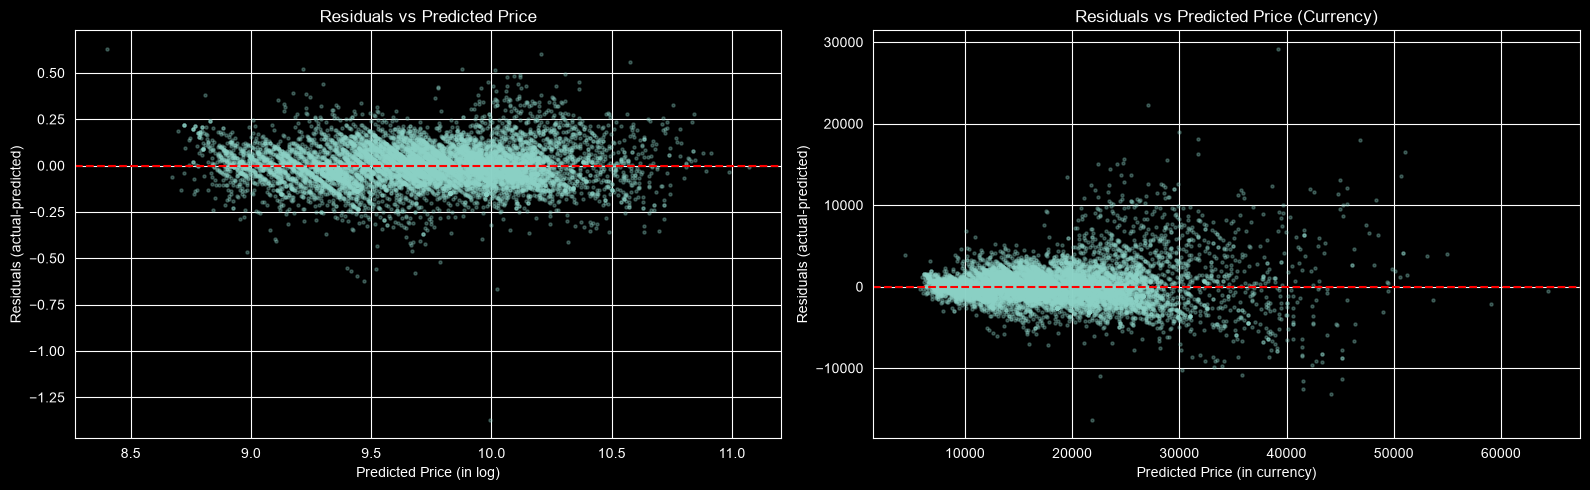

In [41]:
# Linearity check: Plot residuals vs fitted values
y_train_predicted = lr_model.predict(X_train_scaled)
residuals = y_train - y_train_predicted
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(16,5))
axes[0].scatter(x=y_train_predicted,y=residuals,s=5,alpha=0.3)
axes[0].axhline(0,color='red',linestyle='--')
axes[0].set_xlabel('Predicted Price (in log)')
axes[0].set_ylabel('Residuals (actual-predicted)')
axes[0].set_title("Residuals vs Predicted Price")
residuals_currency = np.expm1(y_train) - np.expm1(y_train_predicted) ## since we had taken log of the target
axes[1].scatter(x=np.expm1(y_train_predicted),y=residuals_currency,s=5,alpha=0.3)
axes[1].axhline(0,color='red',linestyle='--')
axes[1].set_xlabel('Predicted Price (in currency)')
axes[1].set_ylabel('Residuals (actual-predicted)')
axes[1].set_title("Residuals vs Predicted Price (Currency)")

plt.tight_layout()
fig.savefig(f"{IMAGES_PATH}residuals_vs_predicted.png",dpi=300,bbox_inches='tight')
plt.show()


Check normality in residual distribution

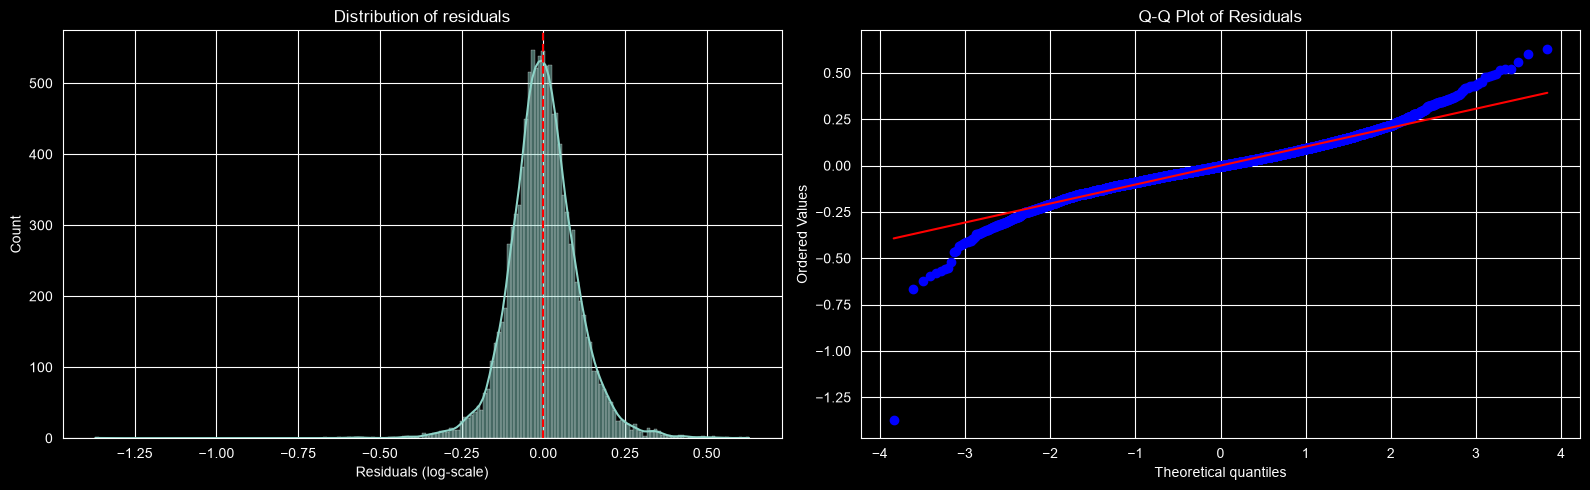

Mean of residuals (should be approx 0) : 0.0
Skew of residuals : -0.064


In [42]:
# Check the normality of residuals by plotting their distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(residuals,kde=True,ax=axes[0])
axes[0].axvline(0,color='red',linestyle='--')
axes[0].set_xlabel('Residuals (log-scale)')
axes[0].set_title('Distribution of residuals')

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
fig.savefig(f"{IMAGES_PATH}residual_normality.png", dpi=150, bbox_inches='tight')
plt.show()

print("Mean of residuals (should be approx 0) :", round(residuals.mean(), 6))
print("Skew of residuals :", round(residuals.skew(), 3))

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [43]:
# Check for multicollinearity and handle
def calculate_vif(features):
    vif_rows = []
    for column in features:
        remaining_features = features.drop(columns=[column])
        r2 = LinearRegression().fit(remaining_features, features[column]).score(remaining_features, features[column])
        vif = np.inf if r2 >=1 else 1/(1-r2)
        vif_rows.append({'feature': column, 'VIF': vif})
    return pd.DataFrame(vif_rows).sort_values(by='VIF', ascending=False).reset_index(drop=True)


In [44]:
vif_df = calculate_vif(X_train_scaled)

print(f"\n Top 15 features from VIF: ")
print(vif_df.head(15).to_string(index=False))
print(f"\n Number of Features with VIF > 10 : {(vif_df['VIF']>10).sum()}")
print(f"\n Number of Features with VIF > 5  : {(vif_df['VIF']>5).sum()}")


 Top 15 features from VIF: 
                              feature        VIF
                                hp_kW 143.475451
                         hp_to_weight  79.495292
                            Weight_kg  25.955754
                                   km  21.917657
                          km_per_year  17.312416
            make_model_Renault Espace  10.571416
                      Displacement_cc   6.990737
             make_model_Opel Insignia   6.837803
                          Fuel_Diesel   6.727392
                        body_type_Van   6.694315
                make_model_Opel Corsa   5.309122
cc_Parking assist system sensors rear   5.060205
                                  age   4.798232
                            cons_comb   4.514831
              body_type_Station wagon   4.499553

 Number of Features with VIF > 10 : 6

 Number of Features with VIF > 5  : 12


In [45]:
high_vif_features = ['hp_to_weight','km_per_year']
X_train_scaled = X_train_scaled.drop(columns=high_vif_features)
X_test_scaled = X_test_scaled.drop(columns=high_vif_features)

new_vif_df = calculate_vif(X_train_scaled)
print(f"\n Top 15 features from New VIF: ")
print(new_vif_df.head(15).to_string(index=False))
print(f"\n Number of Features with New VIF > 10 : {(new_vif_df['VIF']>10).sum()}")
print(f"\n Number of Features with New VIF > 5  : {(new_vif_df['VIF']>5).sum()}")


 Top 15 features from New VIF: 
                              feature       VIF
            make_model_Renault Espace 10.006641
                                hp_kW  7.800694
                      Displacement_cc  6.887218
                          Fuel_Diesel  6.719273
                        body_type_Van  6.672527
             make_model_Opel Insignia  6.608790
                make_model_Opel Corsa  5.304993
cc_Parking assist system sensors rear  5.058937
                            Weight_kg  4.817428
              body_type_Station wagon  4.451482
                            cons_comb  4.431476
             cc_Park Distance Control  4.228740
                make_model_Opel Astra  4.224774
                                  age  3.903794
              make_model_Renault Clio  3.694790

 Number of Features with New VIF > 10 : 1

 Number of Features with New VIF > 5  : 8


In [46]:
new_lr_model = LinearRegression().fit(X_train_scaled, y_train)
new_baseline = evaluate_model('Linear Regression (baseline) - final',new_lr_model, X_train_scaled, X_test_scaled, y_train, y_test)
model_results.append(new_baseline)
pd.DataFrame(model_results)

,model,R2_score_train,R2_score_test,RMSE_train_currency,RMSE_test_currency,MAE_train_currency,MAE_test_currency
0,Linear Regression (baseline),0.932303,0.930153,2229.200375,2283.712675,1432.679163,1462.972683
1,Linear Regression (baseline) - final,0.931146,0.928406,2248.652764,2316.118146,1448.464864,1484.919438


### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [47]:
# List of alphas to tune for Ridge regularisation
ridge_reg_alphas = [0.0001,0.001,0.01,0.1,1,10,100,1000,100000]
print(f"Ridge Regression alphas: {ridge_reg_alphas}")

Ridge Regression alphas: [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 100000]


#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [48]:
def tune_alpha(model,alphas,X_train,y_train,cv=5):
    grid = GridSearchCV(estimator=model,param_grid={'alpha':alphas},scoring='neg_mean_absolute_error',cv=cv,return_train_score=True,n_jobs=-1)
    grid.fit(X_train,y_train)

    results = pd.DataFrame({
        'alpha': np.array(grid.cv_results_['param_alpha'],dtype=float),
        'train_MAE': -grid.cv_results_['mean_train_score'],
        'val_MAE': -grid.cv_results_['mean_test_score']
    }).sort_values('alpha').reset_index(drop=True)

    return grid,results

In [49]:
def plot_alpha_curve(results:pd.DataFrame,img_title:str,img_name:str) -> None:
    plt.figure(figsize=(10,5))
    plt.plot(results['alpha'],results['train_MAE'],marker='o',label='Training MAE')
    plt.plot(results['alpha'],results['val_MAE'],marker='o',label='Validation MAE')
    plt.xscale('log')
    plt.xlabel('alpha (log scale)')
    plt.ylabel('Mean Absolute Error (price in log)')
    plt.title(img_title)
    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{IMAGES_PATH}{img_name}.png",dpi=300,bbox_inches='tight')
    plt.show()

In [50]:
# Applying Ridge regression
ridge_grid, ridge_results = tune_alpha(Ridge(),ridge_reg_alphas,X_train_scaled,y_train)
print(ridge_results.to_string(index=False))

      alpha  train_MAE  val_MAE
     0.0001   0.077388 0.078403
     0.0010   0.077388 0.078403
     0.0100   0.077388 0.078403
     0.1000   0.077388 0.078403
     1.0000   0.077389 0.078404
    10.0000   0.077395 0.078407
   100.0000   0.077616 0.078608
  1000.0000   0.083631 0.084517
100000.0000   0.235405 0.235675


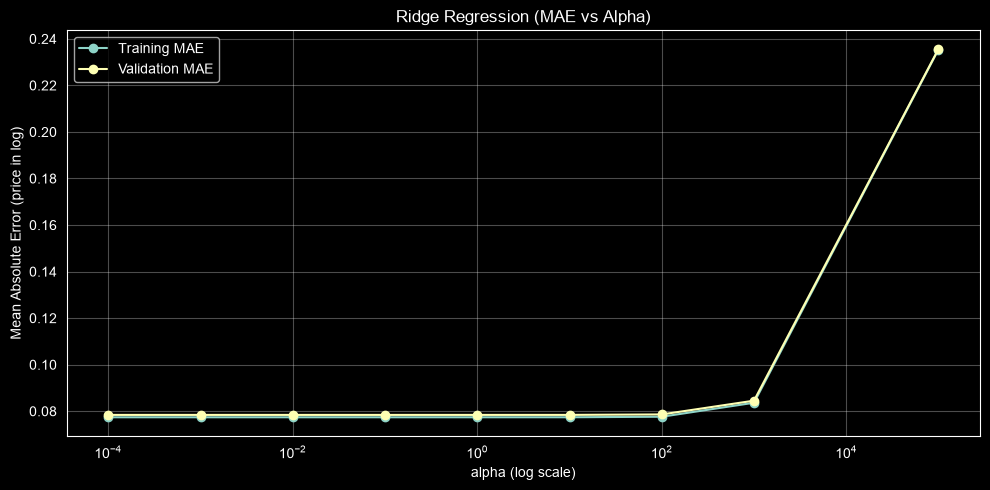

In [51]:
# Plot train and test scores against alpha
plot_alpha_curve(ridge_results,"Ridge Regression (MAE vs Alpha)","ridge_alpha_mae")

Find the best alpha value.

In [52]:
# Best alpha value
print(f"Best Alpha: {ridge_grid.best_params_['alpha']}")

# Best score (negative MAE)
print(f"Best Score: {-ridge_grid.best_score_:.5f}")


Best Alpha: 0.0001
Best Score: 0.07840


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [53]:
# Take a smaller range of alpha to test
ridge_reg_alphas_tuned = np.logspace(-3,3,25)
print(f"Ridge Regression alphas (Tuned): {ridge_reg_alphas_tuned.round(4)}")

Ridge Regression alphas (Tuned): [1.000000e-03 1.800000e-03 3.200000e-03 5.600000e-03 1.000000e-02
 1.780000e-02 3.160000e-02 5.620000e-02 1.000000e-01 1.778000e-01
 3.162000e-01 5.623000e-01 1.000000e+00 1.778300e+00 3.162300e+00
 5.623400e+00 1.000000e+01 1.778280e+01 3.162280e+01 5.623410e+01
 1.000000e+02 1.778279e+02 3.162278e+02 5.623413e+02 1.000000e+03]


In [54]:
# Applying Ridge regression
tuned_ridge_grid, tuned_ridge_results = tune_alpha(Ridge(),ridge_reg_alphas_tuned,X_train_scaled,y_train)
print(tuned_ridge_results.to_string(index=False))

      alpha  train_MAE  val_MAE
   0.001000   0.077388 0.078403
   0.001778   0.077388 0.078403
   0.003162   0.077388 0.078403
   0.005623   0.077388 0.078403
   0.010000   0.077388 0.078403
   0.017783   0.077388 0.078403
   0.031623   0.077388 0.078403
   0.056234   0.077388 0.078403
   0.100000   0.077388 0.078403
   0.177828   0.077388 0.078403
   0.316228   0.077388 0.078403
   0.562341   0.077388 0.078403
   1.000000   0.077389 0.078404
   1.778279   0.077389 0.078404
   3.162278   0.077390 0.078404
   5.623413   0.077391 0.078405
  10.000000   0.077395 0.078407
  17.782794   0.077403 0.078414
  31.622777   0.077423 0.078432
  56.234133   0.077475 0.078480
 100.000000   0.077616 0.078608
 177.827941   0.077973 0.078942
 316.227766   0.078796 0.079740
 562.341325   0.080508 0.081429
1000.000000   0.083631 0.084517


Plot the error-alpha graph again and find the actual optimal value for alpha.

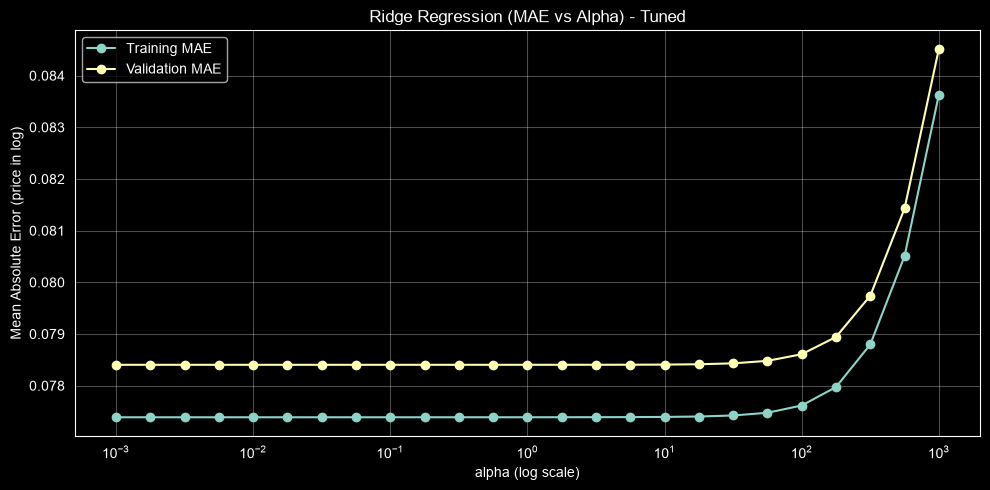

Best alpha  : 0.001
Best score: 0.078403


In [55]:
# Plot train and test scores against alpha
plot_alpha_curve(tuned_ridge_results,"Ridge Regression (MAE vs Alpha) - Tuned","tuned_ridge_alpha_mae")
# Best alpha value
best_ridge_alpha = tuned_ridge_grid.best_params_['alpha']
print(f"Best alpha  : {best_ridge_alpha}")
# Best score (negative MAE)

print(f"Best score: {-tuned_ridge_grid.best_score_:.6f}")

In [56]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model
ridge_model = Ridge(alpha=best_ridge_alpha)
ridge_model.fit(X_train_scaled,y_train)

print(f"Ridge Regression Model fitted with best alpha: {best_ridge_alpha}")

Ridge Regression Model fitted with best alpha: 0.001


In [57]:
# Show the coefficients for each feature
ridge_coefficients = pd.DataFrame({'feature' : X_train_scaled.columns,
                                   'coefficient' : ridge_model.coef_})
ridge_coefficients = ridge_coefficients.reindex(ridge_coefficients['coefficient'].abs().sort_values(ascending=False).index)
print(ridge_coefficients.head(15).to_string(index=False))

                  feature  coefficient
    make_model_Opel Corsa    -0.154543
  make_model_Renault Clio    -0.133178
                    hp_kW     0.102045
                      age    -0.099136
                       km    -0.085715
    make_model_Opel Astra    -0.078606
      Gearing_Type_Manual    -0.058648
make_model_Renault Espace     0.041607
       make_model_Audi A3     0.036001
 make_model_Opel Insignia    -0.023311
        ss_LED Headlights     0.017600
              Fuel_Diesel     0.017072
                    Gears     0.016444
         make_model_Other    -0.015698
       Gearing_Type_Other     0.015498


In [58]:
# Evaluate the Ridge model on the test data
ridge_result = evaluate_model('Ridge',ridge_model,X_train_scaled,X_test_scaled,y_train,y_test)
model_results.append(ridge_result)
pd.DataFrame(model_results)

,model,R2_score_train,R2_score_test,RMSE_train_currency,RMSE_test_currency,MAE_train_currency,MAE_test_currency
0,Linear Regression (baseline),0.932303,0.930153,2229.200375,2283.712675,1432.679163,1462.972683
1,Linear Regression (baseline) - final,0.931146,0.928406,2248.652764,2316.118146,1448.464864,1484.919438
2,Ridge,0.931146,0.928406,2248.652761,2316.118133,1448.464862,1484.919443


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [59]:
# List of alphas to tune for Lasso regularisation
lasso_reg_alphas = [0.00001,0.0001,0.001,0.01,0.1,1]
print(f"Lasso Regression alphas: {lasso_reg_alphas}")

Lasso Regression alphas: [1e-05, 0.0001, 0.001, 0.01, 0.1, 1]


#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [60]:
# Initialise Lasso regression model
lasso_grid,lasso_results = tune_alpha(Lasso(max_iter=1000),lasso_reg_alphas,X_train_scaled,y_train)
print(lasso_results.to_string(index=False))

  alpha  train_MAE  val_MAE
0.00001   0.077388 0.078400
0.00010   0.077398 0.078389
0.00100   0.078015 0.078787
0.01000   0.086272 0.086628
0.10000   0.205710 0.205881
1.00000   0.320847 0.320889


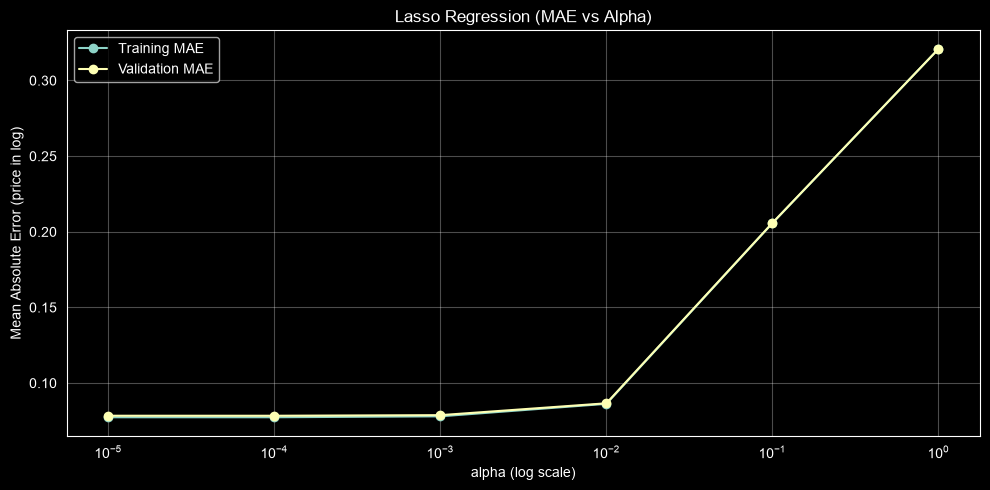

In [61]:
# Plot train and test scores against alpha
plot_alpha_curve(lasso_results, "Lasso Regression (MAE vs Alpha)","lasso_alpha_mae")

In [62]:
# Best alpha value
print(f"Best Alpha: {lasso_grid.best_params_['alpha']}")
# Best score (negative MAE)
print(f"Best score: {-lasso_grid.best_score_:.5f}")


Best Alpha: 0.0001
Best score: 0.07839


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [63]:
# List of alphas to tune for Lasso regularization
lasso_reg_alphas_tuned = [0.00002,0.00005, 0.0001, 0.0002, 0.0005, 0.001]
print(f"Lasso Regression alphas: {np.array(lasso_reg_alphas_tuned,dtype=float).round(6)}")

Lasso Regression alphas: [2.e-05 5.e-05 1.e-04 2.e-04 5.e-04 1.e-03]


In [64]:
# Tuning Lasso hyperparameters
tuned_lasso_grid, tuned_lasso_results = tune_alpha(Lasso(max_iter=1000),lasso_reg_alphas_tuned,X_train_scaled,y_train)
print(tuned_lasso_results.to_string(index=False))

  alpha  train_MAE  val_MAE
0.00002   0.077389 0.078397
0.00005   0.077391 0.078392
0.00010   0.077398 0.078389
0.00020   0.077429 0.078397
0.00050   0.077615 0.078509
0.00100   0.078015 0.078787


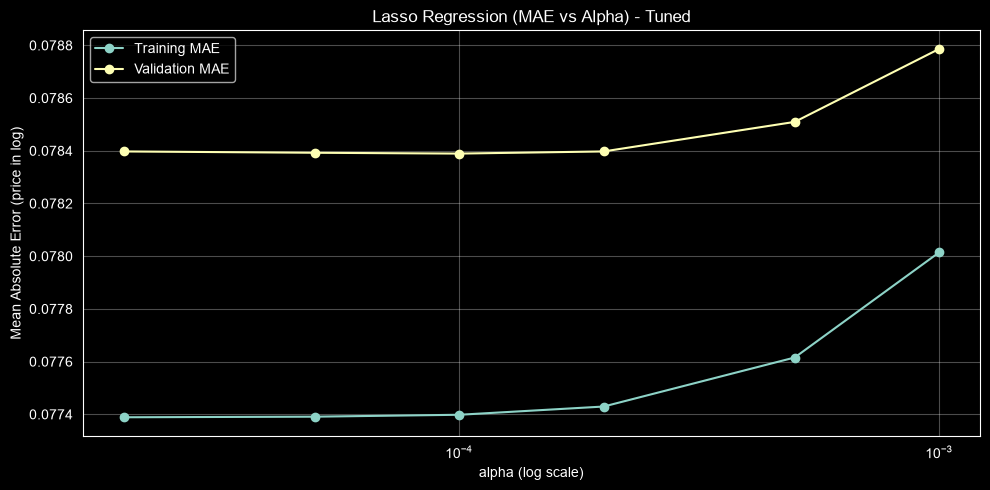

In [65]:
# Plot train and test scores against alpha
plot_alpha_curve(tuned_lasso_results, "Lasso Regression (MAE vs Alpha) - Tuned","tuned_lasso_alpha_mae")

In [66]:
# Best alpha value
best_lasso_alpha = tuned_lasso_grid.best_params_['alpha']
print(f"\nBest Alpha: {best_lasso_alpha}")

# Best score (negative MAE)
print(f"\nBest Score: {-tuned_lasso_grid.best_score_:.5f}")



Best Alpha: 0.0001

Best Score: 0.07839


In [67]:
# Set best alpha for Lasso regression
lasso_model = Lasso(max_iter=1000, alpha=best_lasso_alpha)
# Fit the Lasso model on scaled training data
lasso_model.fit(X_train_scaled,y_train)
# Get the coefficients of the fitted model
print(f"Coefficients of the Fitted Model {lasso_model.coef_}")

Coefficients of the Fitted Model [-8.55573395e-02  1.64787574e-02 -9.94211191e-02 -1.59751458e-03
  1.01380803e-01 -2.86975849e-03 -8.08408925e-03 -1.27880028e-02
  5.21368306e-03  7.49706361e-03  1.80971683e-03 -1.63527601e-03
  3.21280282e-03  7.50672417e-03  1.49554639e-02 -6.53727049e-03
  9.14796989e-03  5.56583989e-03  2.60853098e-03  8.09997623e-04
  4.25290606e-03  5.53663452e-04 -3.76928190e-03  7.11965979e-03
  2.87051393e-03  3.70271909e-03  1.04422748e-02 -7.83119190e-03
  7.60731138e-03  4.43675583e-03  3.46210702e-03  1.08699353e-05
  1.35652684e-03 -3.94032930e-03  8.25298101e-03  4.20676613e-03
  3.54705525e-04 -2.69174545e-05 -4.49100901e-03  2.35553652e-04
 -8.99885209e-03  6.68053863e-04 -3.15557649e-03 -1.65606049e-03
  1.24599457e-02  7.56247412e-03 -4.28564219e-03  1.40401327e-03
  1.17004064e-03  0.00000000e+00  5.41699211e-03  1.99081648e-03
  7.52067166e-03  3.70593114e-03 -4.66708411e-03 -9.46892649e-03
  5.29996976e-03 -3.67390340e-03  4.73833473e-03 -5.74677

In [68]:
# Check the coefficients for each feature
lasso_coefficients = pd.DataFrame({'feature' : X_train_scaled.columns,
                                   'coefficient' : lasso_model.coef_})
dropped_features = lasso_coefficients[lasso_coefficients['coefficient']==0]['feature']
print(f"{len(dropped_features)} features dropped -> {';'.join([dropped_features.to_string(index=False)])}")
print(f"Features Kept: {(lasso_model.coef_!=0).sum()}")

lasso_coefficients = lasso_coefficients.reindex(lasso_coefficients['coefficient'].abs().sort_values(ascending=False).index)
print(lasso_coefficients.head(15).to_string(index=False))

1 features dropped -> ex_Roof rack
Features Kept: 99
                  feature  coefficient
    make_model_Opel Corsa    -0.153932
  make_model_Renault Clio    -0.132111
                    hp_kW     0.101381
                      age    -0.099421
                       km    -0.085557
    make_model_Opel Astra    -0.077868
      Gearing_Type_Manual    -0.058899
make_model_Renault Espace     0.041791
       make_model_Audi A3     0.035930
 make_model_Opel Insignia    -0.022342
        ss_LED Headlights     0.017651
                    Gears     0.016479
         make_model_Other    -0.015723
       Gearing_Type_Other     0.015405
                Type_Used    -0.015399


In [69]:
# Evaluate the Lasso model on the test data
lasso_result = evaluate_model('Lasso Regression',lasso_model,X_train_scaled,X_test_scaled,y_train,y_test)
model_results.append(lasso_result)
pd.DataFrame(model_results)

,model,R2_score_train,R2_score_test,RMSE_train_currency,RMSE_test_currency,MAE_train_currency,MAE_test_currency
0,Linear Regression (baseline),0.932303,0.930153,2229.200375,2283.712675,1432.679163,1462.972683
1,Linear Regression (baseline) - final,0.931146,0.928406,2248.652764,2316.118146,1448.464864,1484.919438
2,Ridge,0.931146,0.928406,2248.652761,2316.118133,1448.464862,1484.919443
3,Lasso Regression,0.931131,0.928426,2250.082369,2316.179019,1449.043722,1484.625590


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [70]:
# Compare metrics for each model
model_comparison = pd.DataFrame(model_results).set_index('model').round(4)
print(model_comparison.to_string())

                                      R2_score_train  R2_score_test  RMSE_train_currency  RMSE_test_currency  MAE_train_currency  MAE_test_currency
model                                                                                                                                              
Linear Regression (baseline)                  0.9323         0.9302            2229.2004           2283.7127           1432.6792          1462.9727
Linear Regression (baseline) - final          0.9311         0.9284            2248.6528           2316.1181           1448.4649          1484.9194
Ridge                                         0.9311         0.9284            2248.6528           2316.1181           1448.4649          1484.9194
Lasso Regression                              0.9311         0.9284            2250.0824           2316.1790           1449.0437          1484.6256


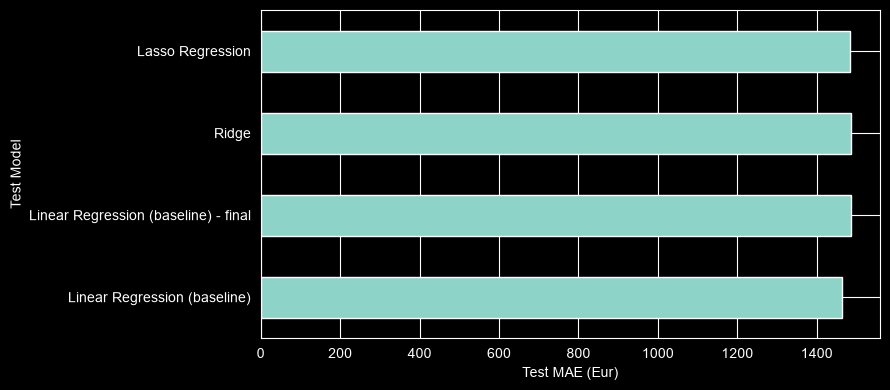

In [71]:
model_comparison['MAE_test_currency'].plot(kind='barh',figsize=(9,4))
plt.xlabel('Test MAE (Eur)')
plt.ylabel('Test Model')
plt.tight_layout()
plt.savefig(f"{IMAGES_PATH}model_comparison_mae.png",dpi=150,bbox_inches='tight')
plt.show()

#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [72]:
# Compare highest coefficients and coefficients of eliminated features
model_coef_comparison =pd.DataFrame({'Linear Model': new_lr_model.coef_,
                                     'Ridge Model': ridge_model.coef_,
                                     'Lasso Model': lasso_model.coef_},index=X_train_scaled.columns)

model_coef_comparison

,Linear Model,Ridge Model,Lasso Model
km,-0.085715,-0.085715,-0.085557
Gears,0.016444,0.016444,0.016479
age,-0.099136,-0.099136,-0.099421
Previous_Owners,-0.001657,-0.001657,-0.001598
hp_kW,0.102045,0.102045,0.101381
...,...,...,...
Paint_Type_Other,0.000450,0.000450,0.000338
Upholstery_type_Part/Full Leather,0.006177,0.006177,0.006190
Gearing_Type_Manual,-0.058648,-0.058648,-0.058899
Gearing_Type_Other,0.015498,0.015498,0.015405


                           Linear Model  Ridge Model  Lasso Model
make_model_Opel Corsa           -0.1545      -0.1545      -0.1539
make_model_Renault Clio         -0.1332      -0.1332      -0.1321
hp_kW                            0.1020       0.1020       0.1014
age                             -0.0991      -0.0991      -0.0994
km                              -0.0857      -0.0857      -0.0856
make_model_Opel Astra           -0.0786      -0.0786      -0.0779
Gearing_Type_Manual             -0.0586      -0.0586      -0.0589
make_model_Renault Espace        0.0416       0.0416       0.0418
make_model_Audi A3               0.0360       0.0360       0.0359
make_model_Opel Insignia        -0.0233      -0.0233      -0.0223


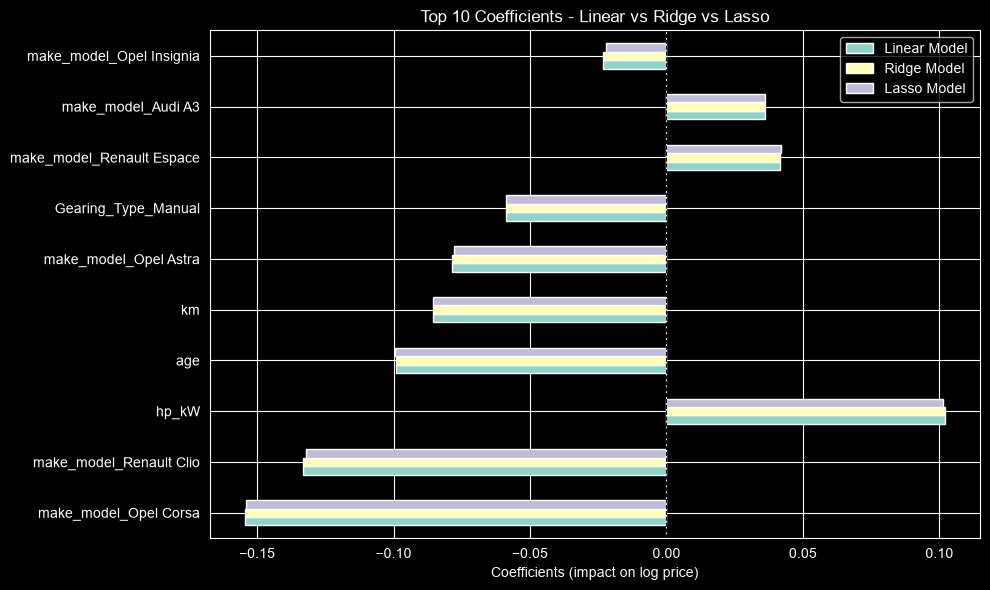


Features removed by Lasso: 
              Linear Model  Ridge Model  Lasso Model
ex_Roof rack        0.0001       0.0001          0.0


In [73]:
top_features = model_coef_comparison['Linear Model'].abs().sort_values(ascending=False).head(10).index
print(model_coef_comparison.loc[top_features].round(4))

model_coef_comparison.loc[top_features].plot(kind='barh',figsize=(10,6))
plt.axvline(0, color='k', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficients (impact on log price)')
plt.title('Top 10 Coefficients - Linear vs Ridge vs Lasso')
plt.tight_layout()
plt.savefig(f"{IMAGES_PATH}top_coefficients_comparison.png",dpi=150,bbox_inches='tight')
plt.show()

eliminated = model_coef_comparison[model_coef_comparison['Lasso Model']==0]
print(f"\nFeatures removed by Lasso: ")
print(eliminated.round(4))

## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

### What did we notice by performing regularisation?

> We found that regularisation almost made no difference to the baseline model. Ridge's best alpha was 0.001 which gave almost exactly the same coefficients and scores as the baseline Linear model.
> Ridge only started to change the model once alpha reach the hundreds. But at that point predictions became worse.
> Lasso found a real best alpha of 0.0002 and removed one feature `(ex_Roof rack)` who's coefficient was already almost zero.

### Did model performance improve ? If not, why ?

> No. All the 3 models scored the same on the test data: R-squared of 0.928, RMSE of approx 2316 Euros and MAE of approx 1485 Euros.
> Ridge and Lasso are designed to reduce the overfitting - but there was no overfitting to reduce so the penalty had nothing to fix.
> Any stronger penalty only made the model less accurate.

### Did we find overfitting ?

> No. Training and test results were almost the same for every model (R-squared 0.931 on training vs 0.928 on test data). Three things kept the model from overfitting.
   > 1. plenty of data -> approximately 11100 training cars for 100 features.
   > 2. careful preparation of data -> rare categories were grouped, near-constant equipment features were removed, and 2 duplicate features were dropped after the VIF check.
   > 3. a linear model is quite simple, so its difficult for it to "learn" from noise data.

### Was the data sufficient?

For this purpose, yes. The data had no missing values, only five clearly impossible records (cars under a year old with over 50k Km) and enough rows to estimate every feature reliably. But there are a few limits to the data:
   > 1. covers only 9 car models from 3 car brands (viz `Audi`, `Opel`, `Renault`)
   > 2. every car is 0 to 3 years old.
   > 3. it comes from only 1 particular German website and its not universal, as in car data from other countries.

### Is a Linear Model sufficient ?

> Mostly, yes. It explains about 93% of the differences in price and the residual plots showed no curved pattern, so a straight line relationship (with the log of price) fits well.
> Weak points are expensive cars; errors increase with high car prices.
> A model that can handle interactions (like engine power matters for few models than for others) could reduce such large misses.
> For dealer's everyday pricing predictions the linear model is accurate enough.

### Business insights for resellers:

1. Use the model as a starting price (approximate price) not as a final price. On average it is about 8% or 1485 Euros of the actual price. In a free market there is no fixed price, so an 8% price band is a sensible starting point for negotiations.
2. Check expensive cars by hand. Errors are large for high-valued cars, so it is better to review the model features before coming to a starting price.
3. Stock decisions: newer, low-mileage, high-powered cars with automatic gearboxes hold the most value.